**BENV0159_Week 2: EDA**<br>
Unitversity College London<br>
Energy Insititue, BSEER<br>
Y Zhang
![logo](../img/logo.png)

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

# Week 2_Practical Overview
***Using NESO's historic electricity demand dataset to answer the following question:
What percentage of GB electricity demand was met by embedded wind + embedded solar?renewable energy.***

## Data overview 
Historic Demand Data from NESO from 2025(https://www.neso.energy/data-portal/historic-demand-data) 

This section contains historic electricity demand, interconnector, hydro storage pumping, Non-BM Short Term Operating Reserve (STOR), wind and solar outturn data.

This dataset is populated 21 days in arrears. It also undergoes retrospective corrections to Solar Capacity and Outturn, once new data becomes available. These corrections may occur several months after the first publication. Retrospective edits to Demand may occur, which make adjustments for Balancing Services undertaken by NESO.

## Aims
By the end of the practical, you will learn:


- How to install and import packages
- How to read/import csv data
- How to use some functions to better understand dataset, df.info(),df.describe(), df.shape() etc.
- How to check the missing data, and process missing data, e.g., df.isnull(), df.fillna() etc.
- How to slice dataset, df.iloc, df.loc
- How to group by data based on categorical data. df.groupby()
- How to create a privot table based on two categotical data df.pivot( )
- How to visualise results using matplotlib and seaborn, e.g., barchart, linechart, heatmap, piechart


In [2]:
#pip install matplotlib
#pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [88]:
import os

In [89]:
os.getcwd()

'/Users/yzhang/Library/Mobile Documents/com~apple~CloudDocs/BENV0159/repo/week_02'

In [90]:
#load packages/modules
import pandas as pd #you can regards it as a nickname
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**read data** pd.read_csv( )


The '=' symbol is the assignment operator in Python. 

It is used to assign a value or an object to a variable. In this case below, the code is reading a CSV file located at the path '/Users/yzhang/Desktop/ECommerce.csv' using the Pandas library's read_csv function, and the resulting DataFrame is assigned to the variable dat. 


In [5]:
import os

In [7]:
os.getcwd()

'/Users/yzhang/Library/Mobile Documents/com~apple~CloudDocs/BENV0159/repo/week_02'

In [104]:
#read the data as dataframe
df = pd.read_csv('data/demanddata_2025.csv')

#check more details about how to use this function. use help() function.
#help(pd.read_csv)
df

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,01/01/2025,1,21036,26215,19918,5405,6606,0,19270,0,...,-1518,-1026,1,-232,-386,-558,96,0,241,0
1,01/01/2025,2,21222,26063,20167,5358,6606,0,19270,0,...,-1513,-1023,1,-124,-282,-564,51,0,262,0
2,01/01/2025,3,21385,25734,20328,5237,6606,0,19270,0,...,-1428,-922,1,-119,-384,-205,62,0,414,0
3,01/01/2025,4,20473,24988,19460,5115,6606,0,19270,0,...,-1423,-915,0,-119,-334,-193,37,0,423,0
4,01/01/2025,5,19634,24912,18654,5080,6606,0,19270,0,...,-1539,-899,0,-119,-363,-622,-282,0,288,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17513,31/12/2025,44,28633,30690,26868,3994,6606,0,22126,0,...,266,-212,912,-345,-145,96,1397,-82,1375,-514
17514,31/12/2025,45,27381,30212,25722,4027,6606,0,22126,0,...,27,-488,831,-432,-254,44,1397,-383,1372,-514
17515,31/12/2025,46,26563,29786,25049,4059,6606,0,22126,0,...,-19,-511,828,-452,-295,38,1368,-402,1370,-514
17516,31/12/2025,47,25481,30558,23955,4115,6606,0,22126,0,...,-1166,-658,622,-452,-383,-431,994,-415,1421,-514



| Column | Meaning |
|---|---|
| `SETTLEMENT_DATE` | Date of the electricity settlement period. |
| `SETTLEMENT_PERIOD` | Half-hour period in the day. `1` = 00:00-00:30, `2` = 00:30-01:00, etc. |
| `ND` | National Demand in MW. GB generation requirement, excluding station load, pumped storage pumping, and interconnector exports. |
| `TSD` | Transmission System Demand in MW. `ND` plus station load, pumped storage pumping, and interconnector exports. |
| `ENGLAND_WALES_DEMAND` | Demand for England and Wales only, similar to `ND` but excluding Scotland. |
| `EMBEDDED_WIND_GENERATION` | Estimated wind generation from distribution-connected wind farms, in MW. |
| `EMBEDDED_WIND_CAPACITY` | Estimated installed embedded wind capacity, in MW. |
| `EMBEDDED_SOLAR_GENERATION` | Estimated solar PV generation connected to distribution networks, in MW. |
| `EMBEDDED_SOLAR_CAPACITY` | Estimated installed embedded solar capacity, in MW. |
| `NON_BM_STOR` | Non-Balancing Mechanism Short-Term Operating Reserve, in MW. Can be generation or demand reduction. |
| `PUMP_STORAGE_PUMPING` | Electricity used for pumped-storage hydro pumping, in MW. Usually shown as negative load. |
| `SCOTTISH_TRANSFER` | Power flow from Scotland to England/Wales, in MW. Negative means England/Wales to Scotland. |
| `IFA_FLOW` | IFA interconnector flow, GB-France. Positive = import into GB; negative = export from GB. |
| `IFA2_FLOW` | IFA2 interconnector flow, GB-France. Positive = import into GB; negative = export from GB. |
| `BRITNED_FLOW` | BritNed interconnector flow, GB-Netherlands. Positive = import into GB; negative = export from GB. |
| `MOYLE_FLOW` | Moyle interconnector flow, Scotland-Northern Ireland. Positive = import into GB; negative = export from GB. |
| `EAST_WEST_FLOW` | East-West interconnector flow, GB-Ireland. Positive = import into GB; negative = export from GB. |
| `NEMO_FLOW` | Nemo Link interconnector flow, GB-Belgium. Positive = import into GB; negative = export from GB. |
| `NSL_FLOW` | North Sea Link interconnector flow, GB-Norway. Positive = import into GB; negative = export from GB. |
| `ELECLINK_FLOW` | ElecLink interconnector flow, GB-France. Positive = import into GB; negative = export from GB. |
| `VIKING_FLOW` | Viking Link interconnector flow, GB-Denmark. Positive = import into GB; negative = export from GB. |
| `GREENLINK_FLOW` | Greenlink interconnector flow, GB-Ireland. Positive = import into GB; negative = export from GB. |


# Understand dataset
## understand the basics of dataset

In [105]:
df.tail(10)

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
17508,31/12/2025,39,34880,37285,32499,3386,6606,0,22126,0,...,382,-1,993,-452,-524,5,1397,27,1208,-514
17509,31/12/2025,40,33407,35704,31187,3557,6606,0,22126,0,...,488,-1,1004,-452,-414,2,1397,30,1211,-514
17510,31/12/2025,41,32389,34523,30259,3683,6606,0,22126,0,...,693,141,1043,-452,-263,408,1397,190,1361,-503
17511,31/12/2025,42,31120,33070,29072,3809,6606,0,22126,0,...,718,142,1045,-452,-138,424,1397,193,1372,-513
17512,31/12/2025,43,29723,31885,27896,3902,6606,0,22126,0,...,317,-181,917,-439,-213,108,1397,-55,1372,-514
17513,31/12/2025,44,28633,30690,26868,3994,6606,0,22126,0,...,266,-212,912,-345,-145,96,1397,-82,1375,-514
17514,31/12/2025,45,27381,30212,25722,4027,6606,0,22126,0,...,27,-488,831,-432,-254,44,1397,-383,1372,-514
17515,31/12/2025,46,26563,29786,25049,4059,6606,0,22126,0,...,-19,-511,828,-452,-295,38,1368,-402,1370,-514
17516,31/12/2025,47,25481,30558,23955,4115,6606,0,22126,0,...,-1166,-658,622,-452,-383,-431,994,-415,1421,-514
17517,31/12/2025,48,24730,30085,23230,4171,6606,0,22126,0,...,-1319,-666,615,-428,-513,-442,928,-414,1416,-514


In [107]:
#check the data features
df.head()
# dat.head(10) #check first 10 rows


,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,01/01/2025,1,21036,26215,19918,5405,6606,0,19270,0,...,-1518,-1026,1,-232,-386,-558,96,0,241,0
1,01/01/2025,2,21222,26063,20167,5358,6606,0,19270,0,...,-1513,-1023,1,-124,-282,-564,51,0,262,0
2,01/01/2025,3,21385,25734,20328,5237,6606,0,19270,0,...,-1428,-922,1,-119,-384,-205,62,0,414,0
3,01/01/2025,4,20473,24988,19460,5115,6606,0,19270,0,...,-1423,-915,0,-119,-334,-193,37,0,423,0
4,01/01/2025,5,19634,24912,18654,5080,6606,0,19270,0,...,-1539,-899,0,-119,-363,-622,-282,0,288,0


In [108]:
df.tail() #check last several rows

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
17513,31/12/2025,44,28633,30690,26868,3994,6606,0,22126,0,...,266,-212,912,-345,-145,96,1397,-82,1375,-514
17514,31/12/2025,45,27381,30212,25722,4027,6606,0,22126,0,...,27,-488,831,-432,-254,44,1397,-383,1372,-514
17515,31/12/2025,46,26563,29786,25049,4059,6606,0,22126,0,...,-19,-511,828,-452,-295,38,1368,-402,1370,-514
17516,31/12/2025,47,25481,30558,23955,4115,6606,0,22126,0,...,-1166,-658,622,-452,-383,-431,994,-415,1421,-514
17517,31/12/2025,48,24730,30085,23230,4171,6606,0,22126,0,...,-1319,-666,615,-428,-513,-442,928,-414,1416,-514


In [109]:
#data dimension
df.shape
#row , column

(17518, 22)

In [110]:
#check the columns/features names
df.columns

Index(['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD',
       'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION',
       'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION',
       'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING',
       'SCOTTISH_TRANSFER', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW',
       'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW',
       'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW'],
      dtype='object')

In [111]:
df.dtypes

SETTLEMENT_DATE              object
SETTLEMENT_PERIOD             int64
ND                            int64
TSD                           int64
ENGLAND_WALES_DEMAND          int64
EMBEDDED_WIND_GENERATION      int64
EMBEDDED_WIND_CAPACITY        int64
EMBEDDED_SOLAR_GENERATION     int64
EMBEDDED_SOLAR_CAPACITY       int64
NON_BM_STOR                   int64
PUMP_STORAGE_PUMPING          int64
SCOTTISH_TRANSFER             int64
IFA_FLOW                      int64
IFA2_FLOW                     int64
BRITNED_FLOW                  int64
MOYLE_FLOW                    int64
EAST_WEST_FLOW                int64
NEMO_FLOW                     int64
NSL_FLOW                      int64
ELECLINK_FLOW                 int64
VIKING_FLOW                   int64
GREENLINK_FLOW                int64
dtype: object

In [112]:
#data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17518 entries, 0 to 17517
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   SETTLEMENT_DATE            17518 non-null  object
 1   SETTLEMENT_PERIOD          17518 non-null  int64 
 2   ND                         17518 non-null  int64 
 3   TSD                        17518 non-null  int64 
 4   ENGLAND_WALES_DEMAND       17518 non-null  int64 
 5   EMBEDDED_WIND_GENERATION   17518 non-null  int64 
 6   EMBEDDED_WIND_CAPACITY     17518 non-null  int64 
 7   EMBEDDED_SOLAR_GENERATION  17518 non-null  int64 
 8   EMBEDDED_SOLAR_CAPACITY    17518 non-null  int64 
 9   NON_BM_STOR                17518 non-null  int64 
 10  PUMP_STORAGE_PUMPING       17518 non-null  int64 
 11  SCOTTISH_TRANSFER          17518 non-null  int64 
 12  IFA_FLOW                   17518 non-null  int64 
 13  IFA2_FLOW                  17518 non-null  int64 
 14  BRITNE

In [113]:
#conduct a data summary statistics of continuous variables
df.describe()

,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
count,17518.000000,17518.000000,17518.000000,17518.000000,17518.000000,17518.0,17518.000000,17518.000000,17518.000000,17518.000000,...,17518.000000,17518.000000,17518.000000,17518.000000,17518.000000,17518.000000,17518.000000,17518.000000,17518.000000,17518.000000
mean,24.497374,26158.733360,28563.740039,23996.801690,1951.031796,6606.0,2130.465578,20813.075522,0.000228,172.484530,...,1179.998059,652.086825,50.369391,-254.854036,-192.348499,227.185695,1023.027343,672.424991,290.306656,-321.350896
std,13.852404,6172.975105,6108.043781,5650.875704,1279.398302,0.0,3282.091732,840.120306,0.021369,318.346745,...,686.906947,483.145770,723.106274,219.912683,237.642542,676.731751,636.629064,440.434194,854.483070,280.487005
min,1.000000,12803.000000,15297.000000,12040.000000,125.000000,6606.0,0.000000,19270.000000,0.000000,0.000000,...,-2071.000000,-1028.000000,-1093.000000,-453.000000,-532.000000,-1024.000000,-1453.000000,-1023.000000,-1453.000000,-539.000000
25%,12.250000,21434.000000,23897.250000,19639.250000,927.000000,6606.0,0.000000,20179.000000,0.000000,5.000000,...,979.000000,254.000000,-592.000000,-451.000000,-492.000000,-305.000000,917.000000,218.250000,-456.750000,-514.000000
50%,24.000000,24960.000000,27269.500000,22904.500000,1604.000000,6606.0,7.000000,20988.000000,0.000000,12.000000,...,1357.000000,984.000000,0.000000,-345.000000,-48.000000,348.000000,1395.000000,991.000000,461.000000,-506.500000
75%,36.000000,29825.750000,32195.750000,27386.750000,2756.000000,6606.0,3483.000000,21510.000000,0.000000,170.000000,...,1510.000000,992.000000,783.000000,-35.250000,0.000000,886.000000,1397.000000,996.000000,989.000000,-138.000000
max,48.000000,45924.000000,47760.000000,41835.000000,5922.000000,6606.0,14046.000000,22126.000000,2.000000,1739.000000,...,2024.000000,1058.000000,1116.000000,400.000000,504.000000,1063.000000,1491.000000,1063.000000,1428.000000,506.000000


In [114]:
#check if there are some missing data

df.isnull()

#False indicates there is no missing data. False indicates the data is missing

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17513,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17514,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17515,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17516,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [115]:
df.isnull().sum()

SETTLEMENT_DATE              0
SETTLEMENT_PERIOD            0
ND                           0
TSD                          0
ENGLAND_WALES_DEMAND         0
EMBEDDED_WIND_GENERATION     0
EMBEDDED_WIND_CAPACITY       0
EMBEDDED_SOLAR_GENERATION    0
EMBEDDED_SOLAR_CAPACITY      0
NON_BM_STOR                  0
PUMP_STORAGE_PUMPING         0
SCOTTISH_TRANSFER            0
IFA_FLOW                     0
IFA2_FLOW                    0
BRITNED_FLOW                 0
MOYLE_FLOW                   0
EAST_WEST_FLOW               0
NEMO_FLOW                    0
NSL_FLOW                     0
ELECLINK_FLOW                0
VIKING_FLOW                  0
GREENLINK_FLOW               0
dtype: int64

In [116]:
df.nunique()

SETTLEMENT_DATE                365
SETTLEMENT_PERIOD               48
ND                           11863
TSD                          11805
ENGLAND_WALES_DEMAND         11544
EMBEDDED_WIND_GENERATION      4660
EMBEDDED_WIND_CAPACITY           1
EMBEDDED_SOLAR_GENERATION     5813
EMBEDDED_SOLAR_CAPACITY        299
NON_BM_STOR                      2
PUMP_STORAGE_PUMPING          1356
SCOTTISH_TRANSFER             6426
IFA_FLOW                      2595
IFA2_FLOW                     1609
BRITNED_FLOW                  2007
MOYLE_FLOW                     809
EAST_WEST_FLOW                 804
NEMO_FLOW                     2041
NSL_FLOW                      1861
ELECLINK_FLOW                 1368
VIKING_FLOW                   2506
GREENLINK_FLOW                1004
dtype: int64

## subset data

Before diving into EDA, let's do a quick review of df subset

In [117]:
df.columns

Index(['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD', 'ND', 'TSD',
       'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION',
       'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION',
       'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING',
       'SCOTTISH_TRANSFER', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW',
       'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW',
       'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW'],
      dtype='object')

In [118]:
#as we only interested in reneable energy (solar and wind), so we can extract the essential columns first
# first create a list of columns we need for further analyis
cols = [
    "SETTLEMENT_DATE",
    "SETTLEMENT_PERIOD",
    "ND",
    "EMBEDDED_WIND_GENERATION",
    "EMBEDDED_SOLAR_GENERATION",
]

In [119]:
df2 = df[cols]
df2

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION
0,01/01/2025,1,21036,5405,0
1,01/01/2025,2,21222,5358,0
2,01/01/2025,3,21385,5237,0
3,01/01/2025,4,20473,5115,0
4,01/01/2025,5,19634,5080,0
...,...,...,...,...,...
17513,31/12/2025,44,28633,3994,0
17514,31/12/2025,45,27381,4027,0
17515,31/12/2025,46,26563,4059,0
17516,31/12/2025,47,25481,4115,0


EMBEDDED_WIND_GENERATION and EMBEDDED_SOLAR_GENERATION are renewable electricity generation estimates from wind and solar assets connected to the distribution network, rather than directly to the high-voltage transmission network. Because they are connected “inside” the distribution system, NESO calls them embedded generation.

In [120]:
#to make the dataset easier to understand, we can rename columns


df2 = df2.rename(columns={
    "SETTLEMENT_DATE": "date",
    "SETTLEMENT_PERIOD": "period",
    "ND": "GB_demand",
    "EMBEDDED_WIND_GENERATION": "wind_generation",
    "EMBEDDED_SOLAR_GENERATION": "solar_generation"})

df2

,date,period,GB_demand,wind_generation,solar_generation
0,01/01/2025,1,21036,5405,0
1,01/01/2025,2,21222,5358,0
2,01/01/2025,3,21385,5237,0
3,01/01/2025,4,20473,5115,0
4,01/01/2025,5,19634,5080,0
...,...,...,...,...,...
17513,31/12/2025,44,28633,3994,0
17514,31/12/2025,45,27381,4027,0
17515,31/12/2025,46,26563,4059,0
17516,31/12/2025,47,25481,4115,0


## datetime datatype

In [121]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17518 entries, 0 to 17517
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              17518 non-null  object
 1   period            17518 non-null  int64 
 2   GB_demand         17518 non-null  int64 
 3   wind_generation   17518 non-null  int64 
 4   solar_generation  17518 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 684.4+ KB


In [123]:
df2

,date,period,GB_demand,wind_generation,solar_generation
0,01/01/2025,1,21036,5405,0
1,01/01/2025,2,21222,5358,0
2,01/01/2025,3,21385,5237,0
3,01/01/2025,4,20473,5115,0
4,01/01/2025,5,19634,5080,0
...,...,...,...,...,...
17513,31/12/2025,44,28633,3994,0
17514,31/12/2025,45,27381,4027,0
17515,31/12/2025,46,26563,4059,0
17516,31/12/2025,47,25481,4115,0


In [125]:
df2["date"] = pd.to_datetime(df2["date"], format="%d/%m/%Y")

In [126]:
df2.info()
#now you can see the Dtype of date is datetime64[ns], which means we converted it succussfully

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17518 entries, 0 to 17517
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              17518 non-null  datetime64[ns]
 1   period            17518 non-null  int64         
 2   GB_demand         17518 non-null  int64         
 3   wind_generation   17518 non-null  int64         
 4   solar_generation  17518 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 684.4 KB


In [127]:
# create a new column that includes both data and hour, min information 

df2["datetime"] = df2["date"] + pd.to_timedelta(
    (df2["period"] - 1) * 30,
    unit="min"
)

# This step is a bit complicated. If you find it difficult to understand, that's completely fine.
# You are not required to master this step at this stage.

In [128]:
df2.datetime.dtype

# someone may ask why it is not datetime64[ns].
#actually they are refering to the samething, you can check datatype by run df2.info() and it will then show datetime64[ns] 


dtype('<M8[ns]')

In [129]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17518 entries, 0 to 17517
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              17518 non-null  datetime64[ns]
 1   period            17518 non-null  int64         
 2   GB_demand         17518 non-null  int64         
 3   wind_generation   17518 non-null  int64         
 4   solar_generation  17518 non-null  int64         
 5   datetime          17518 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(4)
memory usage: 821.3 KB


# EDA_Visualistion

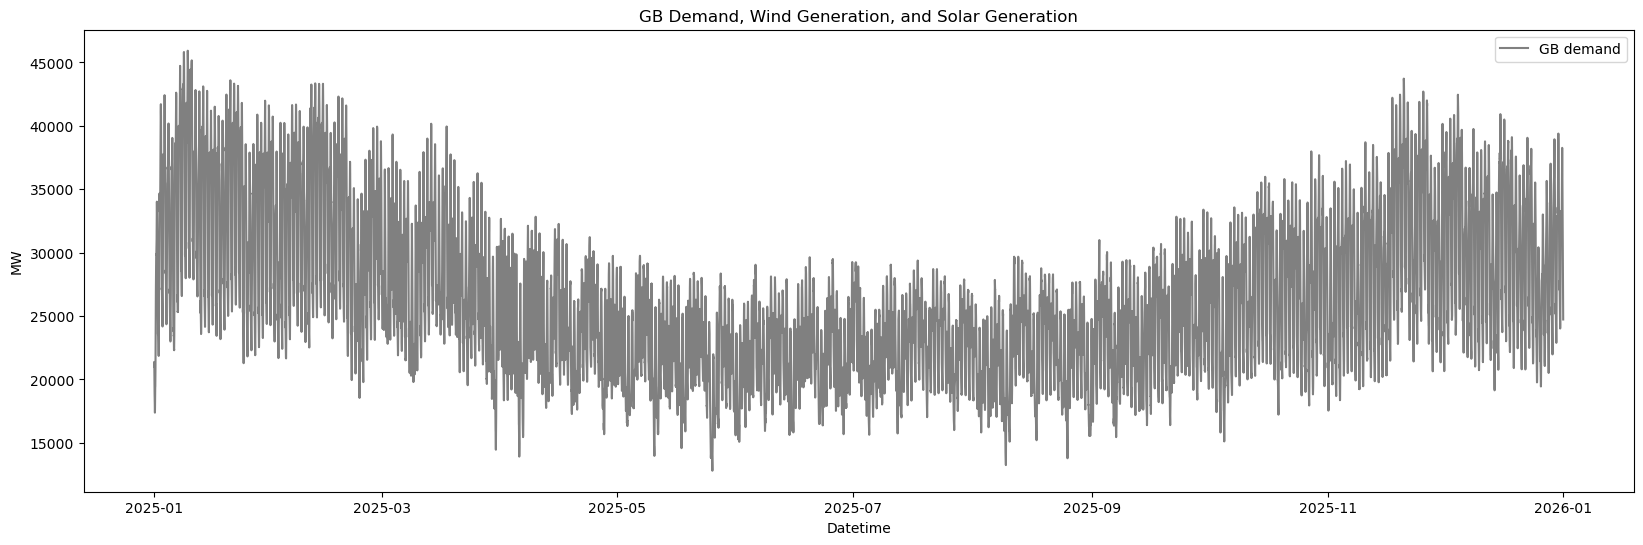

In [130]:
plt.figure(figsize=(20, 6))

plt.plot(df2["datetime"], df2["GB_demand"], label="GB demand", color="grey")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.title("GB Demand, Wind Generation, and Solar Generation")
plt.legend()

## Because `datetime` contains both the date and half-hour settlement period,
# pandas/matplotlib can use it to place the observations in time order.
# Sorting makes this explicit, so the line plot goes from earliest to latest.

### daily plot

the plot above is bit messay but still we can see the patterns.e..g, peaks in summer and winter

The original data is half-hourly, meaning each day has about 48 observations. To make the daily pattern clearer, we can first select one date, then plot GB demand across the day. Because the datetime column includes both date and time, Python can order the points correctly from midnight to the end of the day.

In [131]:
# choose one day
selected_day = "2025-10-01"

# filter data for that day
daily_df = df2[df2["date"] == selected_day]
daily_df

,date,period,GB_demand,wind_generation,solar_generation,datetime
13102,2025-10-01,1,21621,1894,0,2025-10-01 00:00:00
13103,2025-10-01,2,21381,1932,0,2025-10-01 00:30:00
13104,2025-10-01,3,20761,1965,0,2025-10-01 01:00:00
13105,2025-10-01,4,20886,1997,0,2025-10-01 01:30:00
13106,2025-10-01,5,20576,2029,0,2025-10-01 02:00:00
13107,2025-10-01,6,20082,2060,0,2025-10-01 02:30:00
13108,2025-10-01,7,19863,2099,0,2025-10-01 03:00:00
13109,2025-10-01,8,19679,2137,0,2025-10-01 03:30:00
13110,2025-10-01,9,19542,2166,0,2025-10-01 04:00:00
13111,2025-10-01,10,19258,2195,0,2025-10-01 04:30:00


Text(0.5, 1.0, 'Half-hourly GB Electricity Demand on 2025-10-01')

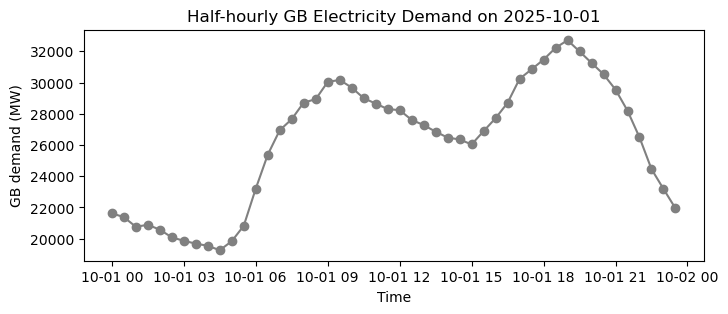

In [132]:
# plot GB demand
plt.figure(figsize=(8, 3)) # set the figure size width, height

plt.plot(
    daily_df["datetime"],
    daily_df["GB_demand"],
    color="grey",
    marker="o" ## o is for circle, you can also specify marker="s"   # square
)

plt.xlabel("Time")
plt.ylabel("GB demand (MW)")
plt.title(f"Half-hourly GB Electricity Demand on {selected_day}")



What if we want to aggregate all the 2025 data and plot the half-hourly demand on a daily basis?

Here we group the data by period, which represents each half-hour time slot in a day. Then we calculate the average GB demand, wind generation, and solar generation for each period. This gives us a typical daily curve instead of showing every single day separately.

In [134]:
# first we need to use a useful function, groupby
daily_pattern =df2.groupby('period')[ ["GB_demand", 'wind_generation', 'solar_generation']].mean().reset_index()
daily_pattern

,period,GB_demand,wind_generation,solar_generation
0,1,22923.989041,1932.117808,0.000000
1,2,22902.901370,1925.443836,0.000000
2,3,22557.268493,1917.780822,0.000000
3,4,22229.893151,1909.600000,0.000000
4,5,21846.947945,1901.545205,0.000000
5,6,21430.465753,1893.035616,0.000000
6,7,21009.863014,1887.917808,0.000000
7,8,20724.400000,1882.282192,0.000000
8,9,20444.671233,1876.717808,0.000000
9,10,20361.684932,1870.646575,0.008219


In [135]:
# Convert settlement period into hour of day
# period 1 = 00:00, period 2 = 00:30, period 3 = 01:00, etc.
daily_pattern["hour_of_day"] = (daily_pattern["period"] - 1) / 2
daily_pattern

,period,GB_demand,wind_generation,solar_generation,hour_of_day
0,1,22923.989041,1932.117808,0.000000,0.0
1,2,22902.901370,1925.443836,0.000000,0.5
2,3,22557.268493,1917.780822,0.000000,1.0
3,4,22229.893151,1909.600000,0.000000,1.5
4,5,21846.947945,1901.545205,0.000000,2.0
5,6,21430.465753,1893.035616,0.000000,2.5
6,7,21009.863014,1887.917808,0.000000,3.0
7,8,20724.400000,1882.282192,0.000000,3.5
8,9,20444.671233,1876.717808,0.000000,4.0
9,10,20361.684932,1870.646575,0.008219,4.5


In [141]:
# create new columns for renewables

daily_pattern ['renewable'] = daily_pattern ['wind_generation'] + daily_pattern ['solar_generation']
daily_pattern['renewable_ratio']  = daily_pattern ['renewable']/ daily_pattern ['GB_demand']

Text(0.5, 1.0, 'Average Embedded Wind and Solar Generation as Share of GB Demand')

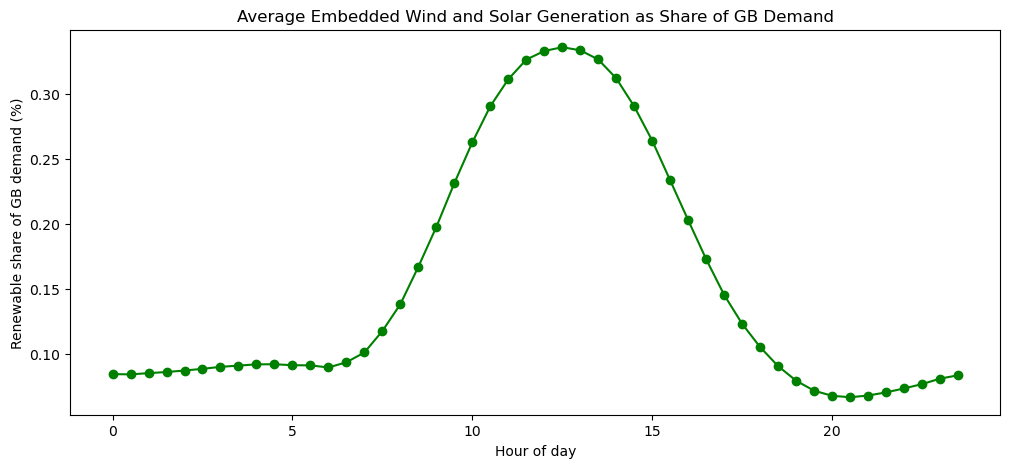

In [142]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_pattern["hour_of_day"],
    daily_pattern["renewable_ratio"],
    color="green",
    marker="o",
    label="Renewable share"
)

plt.xlabel("Hour of day")
plt.ylabel("Renewable share of GB demand (%)")
plt.title("Average Embedded Wind and Solar Generation as Share of GB Demand")


In [154]:
df2

,date,period,GB_demand,wind_generation,solar_generation,datetime,month
0,2025-01-01,1,21036,5405,0,2025-01-01 00:00:00,1
1,2025-01-01,2,21222,5358,0,2025-01-01 00:30:00,1
2,2025-01-01,3,21385,5237,0,2025-01-01 01:00:00,1
3,2025-01-01,4,20473,5115,0,2025-01-01 01:30:00,1
4,2025-01-01,5,19634,5080,0,2025-01-01 02:00:00,1
...,...,...,...,...,...,...,...
17513,2025-12-31,44,28633,3994,0,2025-12-31 21:30:00,12
17514,2025-12-31,45,27381,4027,0,2025-12-31 22:00:00,12
17515,2025-12-31,46,26563,4059,0,2025-12-31 22:30:00,12
17516,2025-12-31,47,25481,4115,0,2025-12-31 23:00:00,12


### monthly plot

here we want to plot 12 curves to show demand changes on daily basis 

After converting date into a datetime column, we can use .dt to extract parts of the date. Here, .dt.month gives the month number for each row, so we can group the data by month and compare typical daily demand curves across the year.

In [143]:
# create month column
df2["month"] = df2["date"].dt.month

In [146]:
monthly_daily_pattern = df2.groupby(["month", "period"])["GB_demand"].mean().reset_index()
monthly_daily_pattern 

,month,period,GB_demand
0,1,1,26719.483871
1,1,2,27091.225806
2,1,3,26788.419355
3,1,4,26266.161290
4,1,5,25736.774194
...,...,...,...
571,12,44,29954.516129
572,12,45,28404.258065
573,12,46,27028.677419
574,12,47,25661.870968


In [147]:
# reshape data for heatmap
heatmap_data = monthly_daily_pattern.pivot(
    index="month",
    columns="period",
    values="GB_demand"
)
heatmap_data

period,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
month,,,,,,,,,,,,,,,,,,,,,
1,26719.483871,27091.225806,26788.419355,26266.161290,25736.774194,25383.580645,24927.580645,24547.451613,24202.193548,24127.193548,...,39783.000000,38736.483871,37549.096774,36282.064516,34642.548387,33039.903226,31256.096774,29616.419355,27990.193548,26957.774194
2,26026.535714,26557.285714,26136.571429,25553.607143,25001.857143,24644.678571,24098.821429,23722.464286,23274.964286,23196.928571,...,38603.178571,37675.642857,36371.500000,35080.785714,33395.178571,31819.321429,30053.285714,28472.857143,26850.250000,25978.714286
3,24351.290323,24765.741935,24445.516129,23884.741935,23407.290323,23038.516129,22582.096774,22338.967742,22113.548387,22166.354839,...,35333.645161,34548.774194,33473.193548,32380.258065,30988.451613,29458.225806,27860.483871,26313.225806,24991.233333,24188.800000
4,21837.333333,21537.233333,21354.133333,21395.633333,21216.766667,20789.500000,20301.666667,20111.300000,19821.033333,19843.333333,...,29126.666667,29334.333333,29677.966667,29420.333333,28614.100000,27597.666667,26156.633333,24762.366667,23309.566667,22406.233333
5,20804.645161,20452.193548,20109.000000,20004.193548,19668.645161,19288.064516,18933.741935,18779.870968,18532.483871,18424.225806,...,26591.838710,26707.225806,26654.580645,26483.838710,26464.354839,25959.000000,25002.870968,23831.645161,22275.838710,21383.580645
6,21051.066667,20659.700000,20250.066667,20045.300000,19673.766667,19253.300000,18829.433333,18627.966667,18303.766667,18078.000000,...,26489.900000,26570.300000,26472.566667,26285.866667,25998.066667,25629.433333,25060.033333,24103.433333,22675.666667,21756.500000
7,21550.838710,21162.000000,20734.580645,20524.516129,20187.451613,19727.193548,19402.064516,19122.419355,18930.612903,18732.967742,...,26709.870968,26813.387097,26673.419355,26475.677419,26273.096774,25962.129032,25270.064516,24293.322581,23032.741935,22090.870968
8,20803.774194,20448.000000,19997.129032,19746.225806,19371.870968,18968.903226,18629.096774,18392.290323,18212.032258,18126.806452,...,26313.000000,26398.774194,26404.225806,26289.129032,25967.870968,25350.064516,24310.903226,23267.645161,22108.451613,21249.806452
9,20810.166667,20422.566667,20149.366667,19968.333333,19718.966667,19294.033333,19042.400000,18813.366667,18622.533333,18614.733333,...,29499.566667,29448.933333,29237.700000,28445.366667,27370.666667,26241.833333,24770.100000,23535.666667,22224.600000,21467.900000


Text(0.5, 1.0, 'Average GB Demand by Month and Half-hour Period')

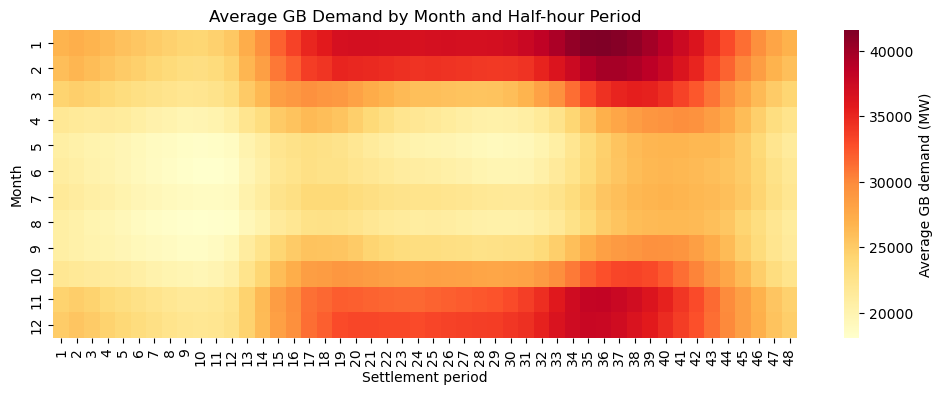

In [150]:
plt.figure(figsize=(12, 4))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    cbar_kws={"label": "Average GB demand (MW)"}
)

plt.xlabel("Settlement period")
plt.ylabel("Month")
plt.title("Average GB Demand by Month and Half-hour Period")

### Exercise
Can you plot a heatmap showing the renewable generation ratio across months and settlement periods?

## other commonly used EDA
### histgram

Text(0.5, 1.0, 'Distribution of GB Demand')

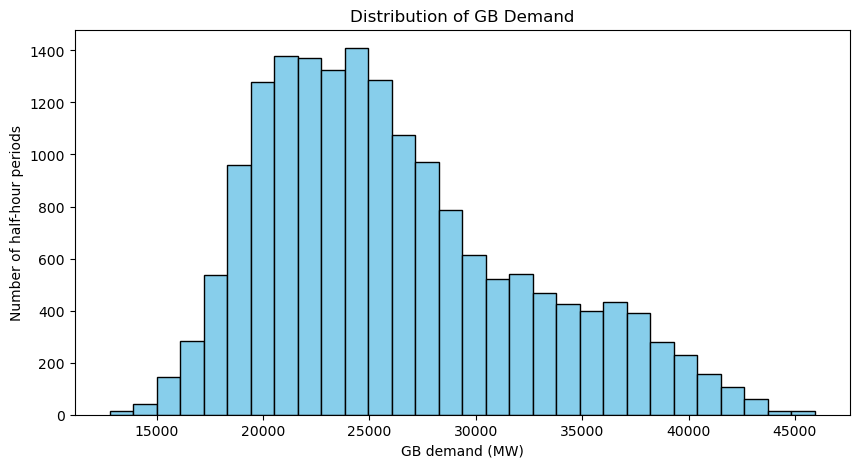

In [156]:
#A histogram shows the distribution of one numeric variable such as GB Demand

plt.figure(figsize=(10, 5))

plt.hist(
    df2["GB_demand"],
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("GB demand (MW)")
plt.ylabel("Number of half-hour periods")
plt.title("Distribution of GB Demand")


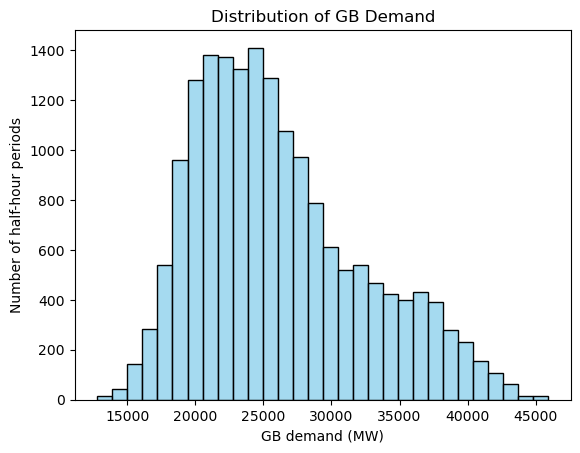

In [157]:
# we can also use sns to plot 
sns.histplot(
    data=df2,
    x="GB_demand",
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("GB demand (MW)")
plt.ylabel("Number of half-hour periods")
plt.title("Distribution of GB Demand")


plt.show()

### boxplot


Text(0.5, 1.0, 'Distribution of GB Demand by Month')

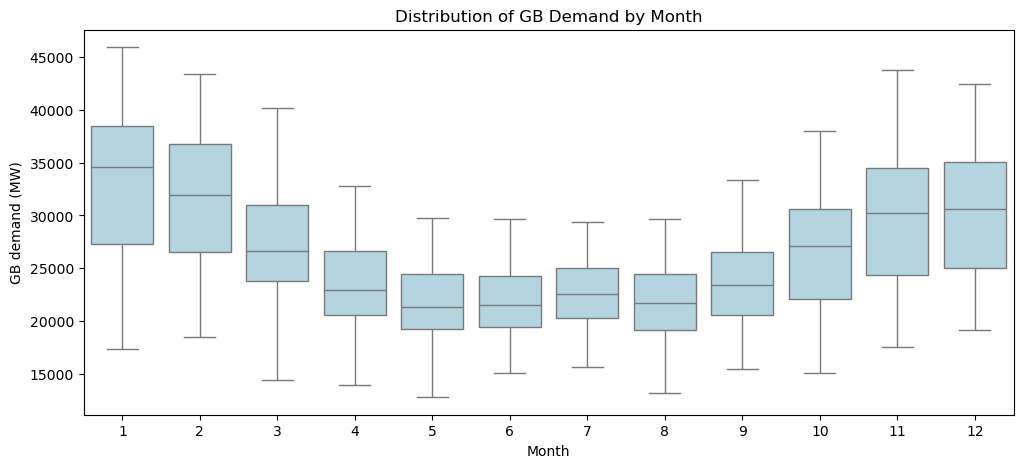

In [160]:
# now plot a boxplot by month

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df2,
    x="month",
    y="GB_demand",
    color="lightblue"
)

plt.xlabel("Month")
plt.ylabel("GB demand (MW)")
plt.title("Distribution of GB Demand by Month")


#### Exercise: 
Can you please do a boxplot to compare the distribution of solar generation across months. It helps us see seasonal differences, such as higher demand in winter and lower demand in summer.

### barchart

In [164]:
df2

,date,period,GB_demand,wind_generation,solar_generation,datetime,month
0,2025-01-01,1,21036,5405,0,2025-01-01 00:00:00,1
1,2025-01-01,2,21222,5358,0,2025-01-01 00:30:00,1
2,2025-01-01,3,21385,5237,0,2025-01-01 01:00:00,1
3,2025-01-01,4,20473,5115,0,2025-01-01 01:30:00,1
4,2025-01-01,5,19634,5080,0,2025-01-01 02:00:00,1
...,...,...,...,...,...,...,...
17513,2025-12-31,44,28633,3994,0,2025-12-31 21:30:00,12
17514,2025-12-31,45,27381,4027,0,2025-12-31 22:00:00,12
17515,2025-12-31,46,26563,4059,0,2025-12-31 22:30:00,12
17516,2025-12-31,47,25481,4115,0,2025-12-31 23:00:00,12


In [166]:
monthly_renewables = df2.groupby("month")[["wind_generation", "solar_generation"]].mean().reset_index()
monthly_renewables

,month,wind_generation,solar_generation
0,1,2001.250672,623.363575
1,2,2406.096726,954.082589
2,3,1738.715343,2382.788022
3,4,1414.312500,3320.878472
4,5,1510.091398,3585.339382
5,6,2002.455556,3597.854167
6,7,1188.024194,3179.936156
7,8,1581.700269,2958.754704
8,9,2037.978472,2373.306944
9,10,2272.331317,1146.823925


<Axes: xlabel='month', ylabel='wind_generation'>

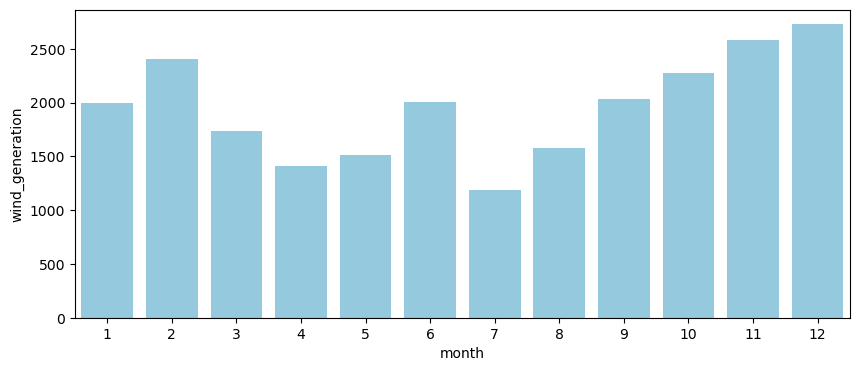

In [168]:
plt.figure(figsize=(10, 4))

sns.barplot(
    data=monthly_renewables,
    x="month",
    y="wind_generation",
    color="skyblue"
)


For other visualisations, please visit this link: https://seaborn.pydata.org/examples/index.html

![gallery](../img/gallery.png)